# Lab: Relationships Between Categorical Features

A fictional telecommunications company wants to understand which customer groups had the greatest observed churn percentages. A customer **churned** if they left the company during the previous month.

You will use the reproducible analysis workflow:

1. **Question:** What do we want to learn?
2. **Data:** Which observations and features can help answer it?
3. **Operation:** What should the code select, calculate, or compare?
4. **Check:** Does the result have the expected rows, columns, units, and possible values?
5. **Evidence:** Which result directly answers the question?
6. **Conclusion:** What claim is supported?
7. **Limitation:** What should we avoid concluding?


## Learning goals

By the end of this lab, you should be able to:

- identify a target feature;
- describe the distribution of a categorical target;
- create count, joint-percentage, and conditional-percentage cross-tabs;
- choose a normalization direction from the question;
- check the denominator represented by a percentage;
- refine the visual design of a categorical comparison; and
- distinguish an observed relationship from a causal claim.


## Using AI tools responsibly

You may use an AI tool to ask questions, debug code, or receive feedback. You remain responsible for understanding and checking every submitted response against the notebook's output.

At the end, disclose whether you used AI. If you did, describe one suggestion you evaluated and what you accepted, modified, or rejected. If you did not, state that clearly.


## Dataset

The dataset was prepared from IBM's [Telco Customer Churn sample](https://www.ibm.com/docs/en/cognos-analytics/12.0.x?topic=samples-telco-customer-churn), a fictional telecommunications dataset created for demonstrations. Each row represents one customer. The seven features below were retained from the source and renamed using `snake_case`.

| Feature | Feature type | Description |
| --- | --- | --- |
| `customer_id` | Identifier | Anonymous customer identifier |
| `contract` | Categorical | Month-to-month, one-year, or two-year contract |
| `internet_service` | Categorical | DSL, fiber optic, or no internet service |
| `tech_support` | Categorical | Technical-support status |
| `payment_method` | Categorical | Customer's payment method |
| `paperless_billing` | Categorical | Whether the customer uses paperless billing |
| `churn` | Categorical target | Whether the customer left during the previous month |

The file contains 7,043 customers and no missing values in the retained fields. Because the data describe a fictional company, the results are useful for practicing an analysis workflow but are not evidence about a real company or the telecommunications industry.


## Prepare the notebook

Import Pandas using its conventional alias `pd` and Matplotlib's `pyplot` component using its conventional alias `plt`.


In [119]:
# Write your code here.
import pandas as pd
import matplotlib.pyplot as plt

## Read the data

Read `data/telco_customer_churn.csv` into a DataFrame named `customers`.


In [120]:
# Write your code here.
customers = pd.read_csv('data/telco_customer_churn.csv')

## Check the data

Display the first five rows.


In [121]:
# Write your code here.
customers.head()

,customer_id,contract,internet_service,tech_support,payment_method,paperless_billing,churn
0,7590-VHVEG,Month-to-month,DSL,No,Electronic check,Yes,No
1,5575-GNVDE,One year,DSL,No,Mailed check,No,No
2,3668-QPYBK,Month-to-month,DSL,No,Mailed check,Yes,Yes
3,7795-CFOCW,One year,DSL,Yes,Bank transfer (automatic),No,No
4,9237-HQITU,Month-to-month,Fiber optic,No,Electronic check,Yes,Yes


## Check the features

Display a summary that includes the feature names, non-missing counts, and Pandas data storage types.


In [122]:
# Write your code here.
customers.info()
# Count the missing values in every feature.
#
# Display the missing-value count for every feature.


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   customer_id        7043 non-null   str  
 1   contract           7043 non-null   str  
 2   internet_service   7043 non-null   str  
 3   tech_support       7043 non-null   str  
 4   payment_method     7043 non-null   str  
 5   paperless_billing  7043 non-null   str  
 6   churn              7043 non-null   str  
dtypes: str(7)
memory usage: 777.4 KB


In [123]:
# Write your code here.
customers.isnull().sum()

customer_id          0
contract             0
internet_service     0
tech_support         0
payment_method       0
paperless_billing    0
churn                0
dtype: int64

A **categorical** feature places observations into groups or labels. A **quantitative** feature records a numerical amount or measurement for which arithmetic is meaningful.


**Complete the table using the results above.** In the data type column, classify each feature as categorical or quantitative. In the data storage type column, record the type reported by Pandas. Different Pandas versions may display text as `str` or `object`.

| Feature | Data type | Data storage type | Missing values |
| --- | --- | --- | ---: |
| `customer_id` | categorical | str | 0 |
| `contract` | categorical | str | 0 |
| `internet_service` | categorical | str | 0 |
| `tech_support` | categorical | str | 0 |
| `payment_method` | categorical | str | 0 |
| `paperless_billing` | categorical | str | 0 |
| `churn` | categorical | str | 0 |


## Identify the target


**Which feature is the target, and what outcome does it represent?**

Your answer: Churn and it represents customers lost in the previous month


## Describe the target distribution with counts

Create and display a Series named `churn_counts`.


In [124]:
# Write your code here.
churn_counts = customers['churn'].value_counts()

churn_counts

churn
No     5174
Yes    1869
Name: count, dtype: int64

**Which target outcome is more frequent?**

Your answer: Customers who didn't churn (No) were more frequent with 5174 customers staying vs only 1869 leaving


## Describe the target distribution with relative frequencies

Create and display a Series named `churn_percent`.


In [125]:
# Write your code here.
churn_percent = (churn_counts / churn_counts.sum()) * 100

churn_percent

churn
No     73.463013
Yes    26.536987
Name: count, dtype: float64

**What percentage of all customers churned?**

Your answer: 26.54%


# Analysis 1: Is churn related to contract type?

Follow the analysis workflow from question through limitation.


In [126]:
customers['contract'].value_counts()

contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

**Before calculating a cross-tab, which contract type do you predict had the greatest churn percentage? Explain your prediction.**

Your answer: Month-to-month customers are more likely to churn. Customers who chose longer contracts imply their commitment.


## Step 1: Question


The question is: **Is churn related to contract type?**


## Step 2: Data

The relevant features are `contract` and `churn`. Before calculating percentages, compare the raw counts in their joint distribution.

Create and display `contract_churn_counts`, with contract types in the rows and churn outcomes in the columns.

Create and display `contract_churn_counts`, with contract types in the rows and churn outcomes in the columns.


In [127]:
# Write your code here.
contract_churn_counts = pd.crosstab(customers['contract'], customers['churn'])

contract_churn_counts

churn,No,Yes
contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


**Which contract type has the greatest raw number of customers who churned?**

Your answer: Month-to-month with 1655 customers lost.


**Do the raw churn counts establish which contract group was most likely to churn? Explain.**

Your answer: No. Raw numbers can't tell the full story since they just state the total losses per category not the rate of churn. Proportionality matters when looking at rates and since each category has different totals, such a conclusion can't be made without looking at the rate of churn.


## Step 3: Operation

To compare likelihood fairly, calculate churn percentages within each contract type. First inspect the group totals.

Recreate the contract/churn cross-tab using `margins=True`.


In [128]:
# Write your code here.
pd.crosstab(customers['contract'], customers['churn'], margins=True)

churn,No,Yes,All
contract,,,
Month-to-month,2220,1655,3875
One year,1307,166,1473
Two year,1647,48,1695
All,5174,1869,7043


**Why do the contract-group totals matter when comparing likelihood?**

Your answer: Even though month-to-month contracts had the highest total amount of churn, their total count is just above double that. Whereas one year contracts' churn ratio is closer to one tenth. Without these group totals, we can't know how much churn impacted the categories.


### Joint percentages

Create and display `contract_joint_percent`. All cells together should add to 100%.


In [129]:
# Write your code here.
contract_joint_percent = pd.crosstab(customers['contract'], customers['churn'], normalize = True) * 100

contract_joint_percent

churn,No,Yes
contract,,
Month-to-month,31.520659,23.498509
One year,18.557433,2.356950
Two year,23.384921,0.681528


## Step 4: Check

Display the sum of every value in `contract_joint_percent`.


In [130]:
# Write your code here.
pd.crosstab(customers['contract'], customers['churn'], normalize = True, margins=True) * 100




churn,No,Yes,All
contract,,,
Month-to-month,31.520659,23.498509,55.019168
One year,18.557433,2.356950,20.914383
Two year,23.384921,0.681528,24.066449
All,73.463013,26.536987,100.000000


**What denominator does each joint percentage use?**

Your answer: Total customers(7043)


**Does the joint-percentage table directly answer which contract group was most likely to churn?**

Your answer: No, we need to compare the churn to each categories total to see true likelihood. This just shows what percent of the whole each cell represents. Month-to-month make up a much larger percentage of the total customers at over 55%.


### Conditional percentages

Create `churn_within_contract` so each row describes churn outcomes within one contract type.


In [131]:
# Write your code here.
churn_within_contract = pd.crosstab(customers['contract'], customers['churn'], normalize='index') * 100

churn_within_contract

churn,No,Yes
contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


### Check the conditional percentages

Display the sum of each row in `churn_within_contract`.


In [132]:
# Write your code here.
churn_within_contract.sum(axis=1)

contract
Month-to-month    100.0
One year          100.0
Two year          100.0
dtype: float64

**What should every row add to, and why?**

Your answer: 100%. This ensures all customers in each row(contract type) are accounted for.


**Which contract group had the greatest observed churn percentage? Report the percentage.**

Your answer: Month-to-month contracts were overwhelmingly more likely to churn with a rate of 42.71% vs. 11.27 and 2.83% for one year and two year respectively.


**Was your prediction supported?**

Your answer: Yes, as predicted, two year contracts had the lowest churn rate(2.83%) followed by one years (11.27%) and monthly at 42.71%. 


## Step 5: Evidence

### Visualize the raw counts

Make a stacked bar chart from `contract_churn_counts`.


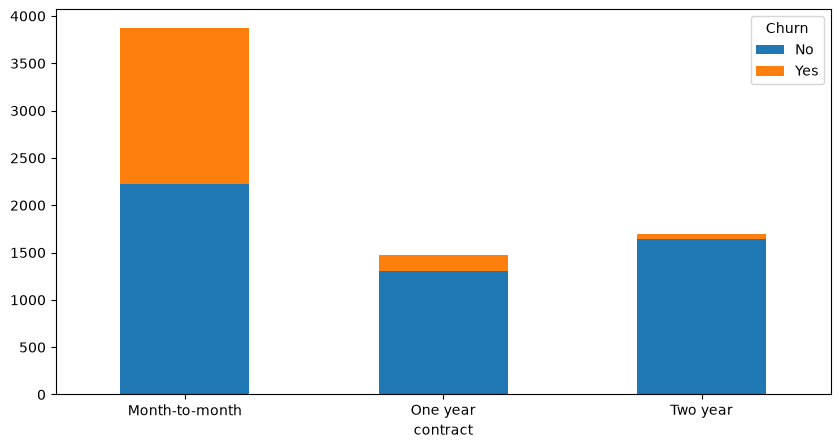

In [133]:
# Write your code here.
contract_churn_counts.plot(
    kind='bar',
    stacked=True,
    figsize=(10,5)
)
plt.xticks(rotation=0)
plt.legend(title='Churn')
plt.show()

### Visualize the conditional percentages

Make a 100% stacked bar chart from `churn_within_contract`. Use:

- `"lightgray"` for customers who did not churn;
- `"steelblue"` for customers who churned;
- a question-focused title;
- descriptive axis labels;
- horizontal x-axis labels; and
- an audience-friendly legend.


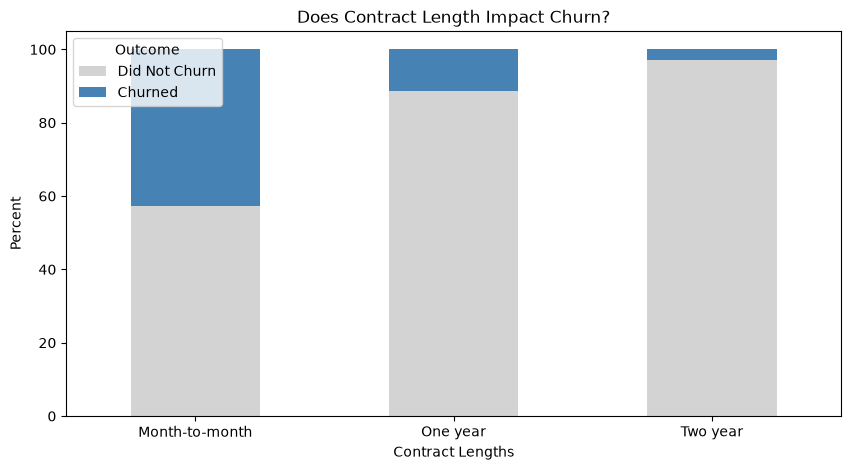

In [134]:
# Write your code here.
churn_within_contract.plot(
    kind='bar',
    stacked=True,
    color=['lightgray', 'steelblue'],
    figsize=(10,5)
)

plt.title("Does Contract Length Impact Churn?")
plt.xlabel('Contract Lengths')
plt.xticks(rotation=0)
plt.ylabel('Percent')
plt.legend(['Did Not Churn', 'Churned'], title='Outcome')
plt.show()

**Which chart answers the likelihood question more clearly: counts or conditional percentages? Explain.**

Your answer: The conditional percentage graph is much clearer at showing the likelihood for churn. By normalizing the rows, the distinction is unmistakable. The counts graph can visually convey the general idea that monthly contracts have a much higher churn rate but you'd still need to calculate the actual percentage.


## Step 6: Conclusion


**What conclusion about contract type and churn is supported by this sample?**

Your answer: Monthly contracts have a much higher churn rate at 42.71% with one year customers at 11.27% and two years at only 2.83%. This was expected as the longer contract customers show a greater likelihood to commit.


## Step 7: Limitation


**Why does this analysis not prove that changing a customer's contract would cause a change in churn?**

Your answer: We have no data on customers' motivations. The data does not say anything about what caused the churn or even why others stayed. It's merely an observation of churn not its cause.


# Analysis 2: Is churn related to payment method?

Apply the same workflow to a second pair of categorical features.


## Step 1: Question


The question is: **Is churn related to payment method?**


## Step 2: Data

Create and display the joint distribution of `payment_method` and `churn` as raw counts. Name it `payment_churn_counts`.

Create and display `payment_churn_counts`.


In [135]:
# Write your code here.
payment_churn_counts = pd.crosstab(customers['payment_method'], customers['churn'])

payment_churn_counts

churn,No,Yes
payment_method,,
Bank transfer (automatic),1286,258
Credit card (automatic),1290,232
Electronic check,1294,1071
Mailed check,1304,308


## Step 3: Operation

Create and display `churn_within_payment`.


In [136]:
# Write your code here.
churn_within_payment = pd.crosstab(customers['payment_method'], customers['churn'], normalize='index') * 100

churn_within_payment

churn,No,Yes
payment_method,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


## Step 4: Check

Display the sum of every row in `churn_within_payment`.


In [137]:
# Write your code here.
churn_within_payment.sum(axis=1)

payment_method
Bank transfer (automatic)    100.0
Credit card (automatic)      100.0
Electronic check             100.0
Mailed check                 100.0
dtype: float64

**Which payment-method group had the greatest observed churn percentage? Report the percentage.**

Your answer: Electronic check customers with a 45.29% rate of churn


## Step 5: Evidence

Make a 100% stacked bar chart. Choose two readable colors that are different from the `"lightgray"` and `"steelblue"` used in the contract chart. Use the same color consistently for each outcome throughout this chart and include audience-friendly labels.


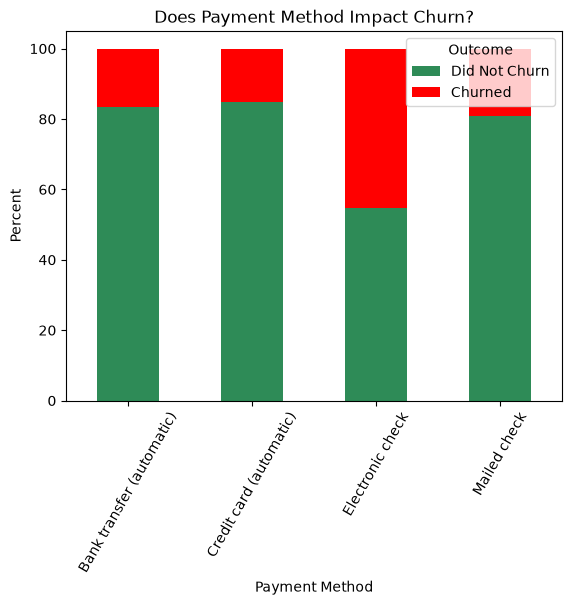

In [138]:
# Write your code here.
churn_within_payment.plot(
    kind='bar',
    stacked=True,
    color=['seagreen', 'red']
)

plt.title('Does Payment Method Impact Churn?')
plt.xlabel('Payment Method')
plt.xticks(rotation=60)
plt.ylabel('Percent')
plt.legend(['Did Not Churn', 'Churned'], title='Outcome')
plt.show()

## Step 6: Conclusion


**What conclusion about payment method and churn is supported by the sample? Include the percentage that provides your strongest evidence.**

Your answer: Electronic check payments had the highest churn rate at 45.29%. This was more than double the rate of other methods.


## Step 7: Limitation


**Why does this analysis not prove that changing a customer's payment method would cause a change in churn?**

Your answer: We still have no data on what caused the churn. Just because the data showed a relationship between payment methods and churn doesn't mean is shows any cause of that behavior. 


## AI-use reflection


State whether you used an AI tool. If you did, identify one suggestion you checked and explain what you accepted, modified, or rejected. If you did not, state that you did not use one.

Your answer: I checked my conclusions with Gemini. It suggested I needed to explicitly state causation is not correlation but I felt that was implied in the way I chose to respond so I rejected its suggestion.


## Submission checklist

- Run every code cell from top to bottom.
- Use all requested object names.
- Complete every written-response cell.
- Check that numerical claims match the output.
- Use named colors and audience-friendly labels.
- Keep code, figures, and written answers neat and easy to read.
- Distinguish an observed relationship from a causal claim.
- Complete the AI-use reflection.
- Submit the completed notebook by the deadline.
